In [1]:
pip install numpy pandas matplotlib seaborn statsmodels scikit-learn


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 5.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 8.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 7.7 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 7.3 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 7.3 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 6.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


TỔNG QUAN CÔNG VIỆC CHƯƠNG 2
Dataset: AirPassengers (Monthly, 1949–1960)
Biến: Passengers
Tần suất: Monthly
Mục tiêu chương 2: Hiểu cấu trúc dữ liệu – chưa dự báo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

plt.rcParams["figure.figsize"] = (10, 5)

TASK 2.1 – Load & khám phá dữ liệu ban đầu
(Bài tập 1 – bước 1)
Mục tiêu
Hiểu dữ liệu là gì
Kiểm tra format time series
Nhìn xu hướng ban đầu
(để file dataset chung thư mục)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


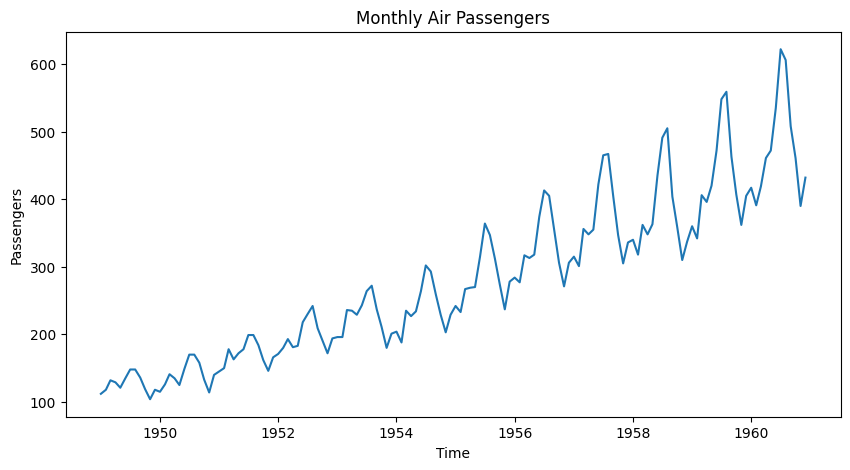

In [2]:
# Load data
df = pd.read_csv("AirPassengers.csv")

# Rename columns cho đẹp (nếu cần)
df.columns = ["Month", "Passengers"]

# Convert to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Set index
df.set_index("Month", inplace=True)

# Xem dữ liệu
print(df.head())
print(df.info())

# Plot
plt.figure()
plt.plot(df.index, df["Passengers"])
plt.title("Monthly Air Passengers")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()


Viết báo cáo 2.1 ở đây (đoạn code trên chỉ là tham khảo, hãy tìm hiểu nó là gì và vì sao như vậy, rồi sửa lại chi tiết nếu muốn)

TASK 2.2 – Phân tích ACF & PACF
(Bài tập 1 – bước 2 & 3)
Mục tiêu
Kiểm tra tự tương quan
Nhận diện trend & seasonality
Xác định lag quan trọng

<Figure size 1000x500 with 0 Axes>

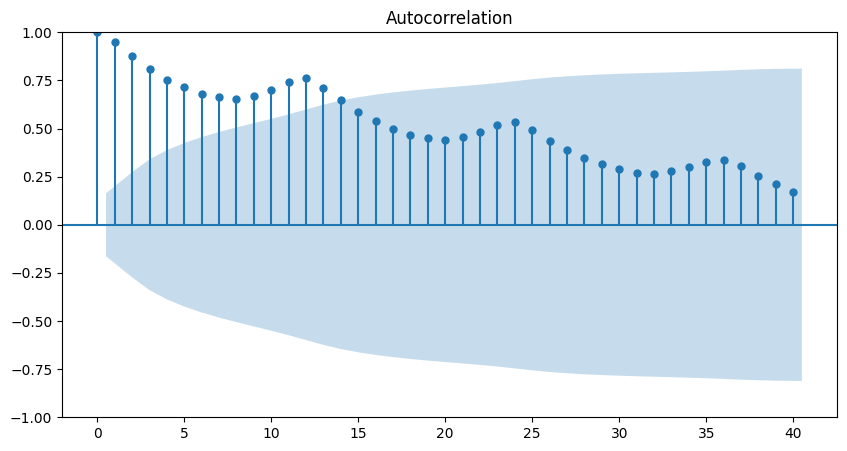

<Figure size 1000x500 with 0 Axes>

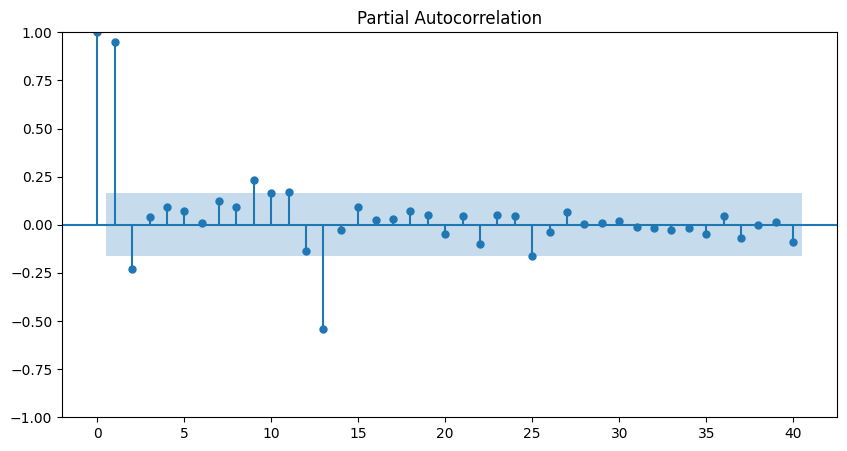

In [3]:
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf (đoạn này đã có ở trên)

plt.figure()
plot_acf(df["Passengers"], lags=40)
plt.show()

plt.figure()
plot_pacf(df["Passengers"], lags=40, method="ywm")
plt.show()


Viết báo cáo 2.2 ở đây (đoạn code trên chỉ là tham khảo, hãy tìm hiểu nó là gì và vì sao như vậy, rồi sửa lại chi tiết nếu muốn)

TASK 2.3 – Kiểm tra White Noise
(Bài tập 2)
Mục tiêu
Hiểu thế nào là white noise
So sánh với chuỗi thật
Kết luận khả năng dự báo

<Figure size 1000x500 with 0 Axes>

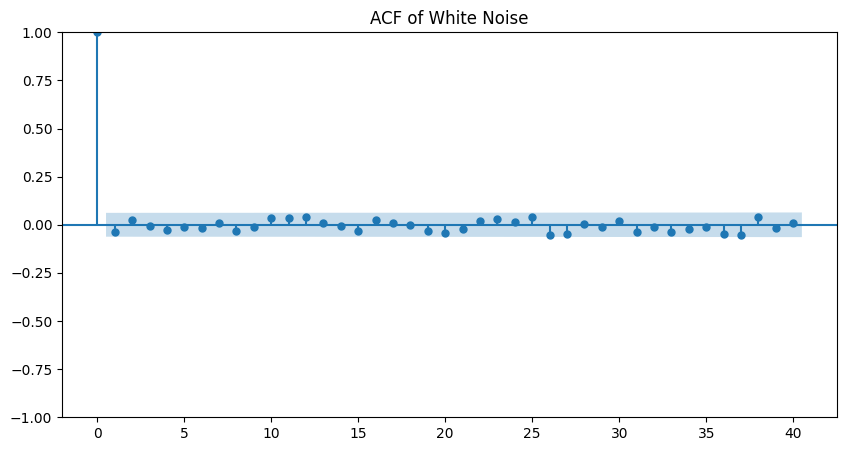

<Figure size 1000x500 with 0 Axes>

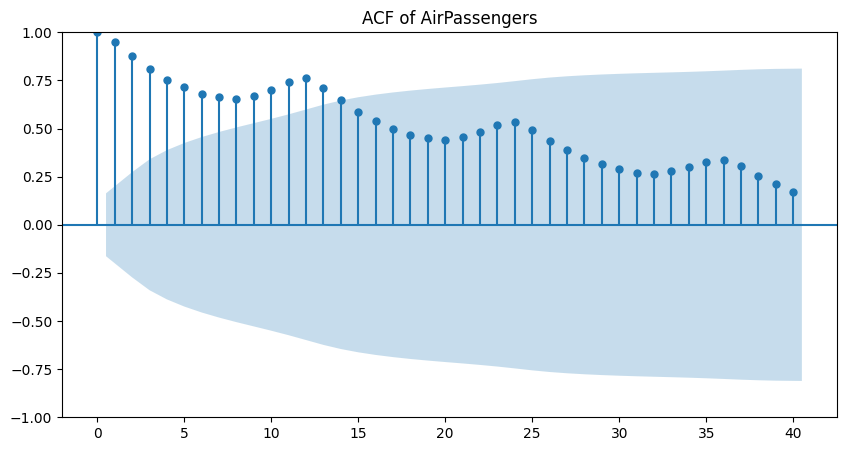

In [4]:
# Sinh white noise
white_noise = np.random.normal(0, 1, 1000)

# Plot ACF white noise
plt.figure()
plot_acf(white_noise, lags=40)
plt.title("ACF of White Noise")
plt.show()

# So sánh với AirPassengers
plt.figure()
plot_acf(df["Passengers"], lags=40)
plt.title("ACF of AirPassengers")
plt.show()

Viết báo cáo 2.3 ở đây (đoạn code trên chỉ là tham khảo, hãy tìm hiểu nó là gì và vì sao như vậy, rồi sửa lại chi tiết nếu muốn)

TASK 2.4 – Phân rã chuỗi thời gian (Decomposition)
(Bài tập 3)
Mục tiêu
Tách trend / seasonal / residual
Kiểm tra residual có giống white noise không

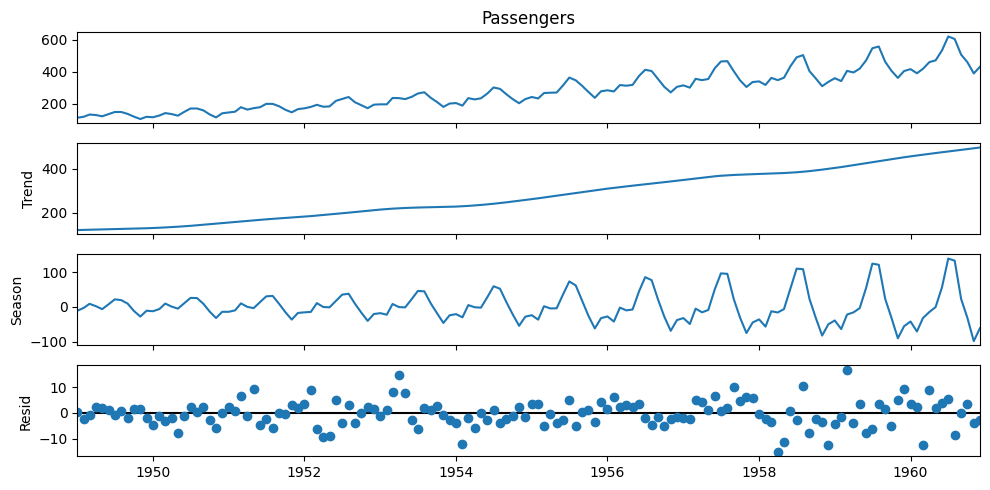

In [5]:
# from statsmodels.tsa.seasonal import STL (đã import ở trên cùng)

stl = STL(df["Passengers"], period=12)
result = stl.fit()

result.plot()
plt.show()

Viết báo cáo 2.4 ở đây (đoạn code trên chỉ là tham khảo, hãy tìm hiểu nó là gì và vì sao như vậy, rồi sửa lại chi tiết nếu muốn)

TASK 2.5 – Kiểm tra & xử lý chất lượng dữ liệu
(Bài tập 4)
Mục tiêu
Thực hành missing & outliers
So sánh trước – sau

Passengers    5
dtype: int64


C:\Users\ACER\AppData\Local\Temp\ipykernel_14040\4209292439.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df_missing.fillna(method="ffill")


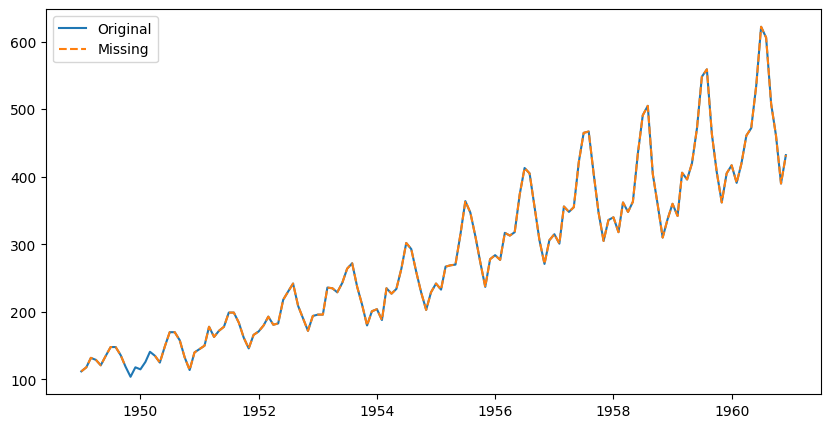

In [6]:
df_missing = df.copy()

# Giả lập missing
df_missing.iloc[10:15] = np.nan

print(df_missing.isna().sum())

# Forward fill
df_ffill = df_missing.fillna(method="ffill")

# Interpolation
df_interp = df_missing.interpolate()

# Plot so sánh
plt.figure()
plt.plot(df, label="Original")
plt.plot(df_missing, label="Missing", linestyle="--")
plt.legend()
plt.show()

Viết báo cáo 2.5 ở đây (đoạn code trên chỉ là tham khảo, hãy tìm hiểu nó là gì và vì sao như vậy, rồi sửa lại chi tiết nếu muốn)

TASK 2.6 – Trực quan hóa toàn bộ dataset
Bài tập 5:
1. Vẽ line chart toàn bộ chuỗi.
2. Vẽ rolling mean (window=12) và rolling std.
3. Vẽ seasonal plot theo tháng (đối với dữ liệu theo tháng).
4. Vẽ heatmap seasonality (month × year).
5. Kết luận: 

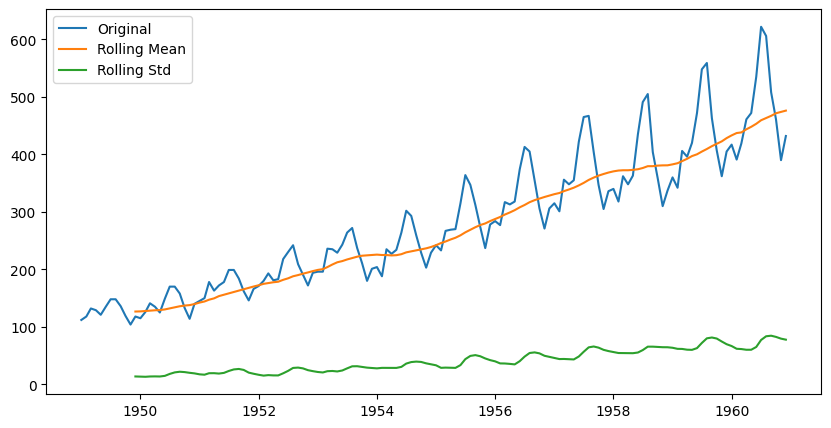

In [7]:
# Rolling mean & std
rolling_mean = df["Passengers"].rolling(12).mean()
rolling_std = df["Passengers"].rolling(12).std()

plt.figure()
plt.plot(df["Passengers"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.show()

Giải thích:

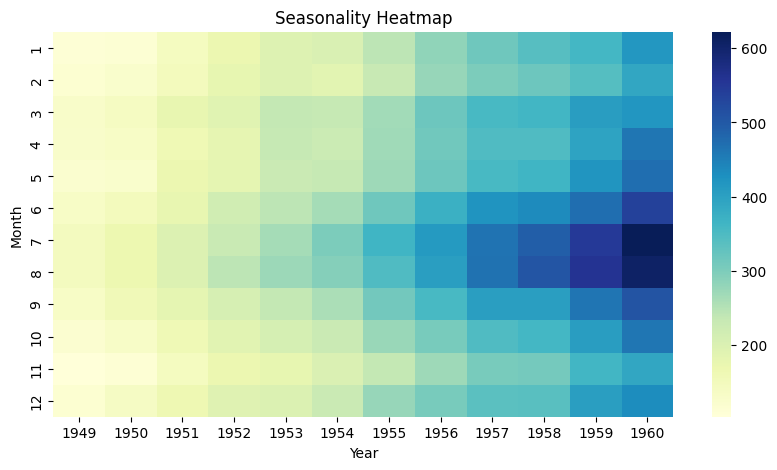

In [8]:
# Heatmap seasonality
# import seaborn as sns (đã import ở trên)

df_season = df.copy()
df_season["Year"] = df_season.index.year
df_season["Month"] = df_season.index.month

pivot = df_season.pivot(index="Month", columns="Year", values="Passengers")

plt.figure()
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Seasonality Heatmap")
plt.show()

Viết kết luận? (nhớ tìm hiểu và so sánh đồng bộ lại coi đã chuẩn với yêu cầu của cô chưa)
(đoạn code trên chỉ là tham khảo, hãy tìm hiểu nó là gì và vì sao như vậy, rồi sửa lại chi tiết nếu muốn)

Viết Kết luận toàn bộ chương 2 ở đây